# Głębokie Uczenie w Praktyce
## Laboratorium 10
### Mateusz Horczak

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

In [45]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Kształt danych treningowych: {x_train.shape}")
print(f"Kształt etykiet: {y_train_cat.shape}")

Kształt danych treningowych: (60000, 28, 28, 1)
Kształt etykiet: (60000, 10)


#### Ćwiczenie 1. Zaimplementuj CVAE

In [46]:
latent_dim = 2  # Wymiar przestrzeni ukrytej

# warstwa próbkująca (sampling)
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

#### Enkoder i dekoder

In [47]:
def build_cvae_models(latent_dim):
    # Enkoder
    encoder_inputs = keras.Input(shape=(28, 28, 1)) # wejscie obrazu
    class_labels = keras.Input(shape=(10,)) # wejscie etykiety

    x_label = layers.Dense(28 * 28 * 1)(class_labels)
    x_label = layers.Reshape((28, 28, 1))(x_label)

    x = layers.Concatenate()([encoder_inputs, x_label]) # polaczenie obrazu i etykiety

    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)

    # wyjscie enkodera (srednia i wariancja rozkladu)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])

    encoder = keras.Model([encoder_inputs, class_labels], [z_mean, z_log_var, z])

    # Dekoder
    latent_inputs = keras.Input(shape=(latent_dim,))
    decoder_labels = keras.Input(shape=(10,))

    x_dec = layers.Concatenate()([latent_inputs, decoder_labels])

    x_dec = layers.Dense(7 * 7 * 64, activation="relu")(x_dec)
    x_dec = layers.Reshape((7, 7, 64))(x_dec)

    x_dec = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x_dec)
    x_dec = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x_dec)
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x_dec)

    decoder = keras.Model([latent_inputs, decoder_labels], decoder_outputs)

    return encoder, decoder

In [48]:
class CVAE(keras.Model):
    def __init__(self, encoder, decoder, beta_kl=1.0, **kwargs):
        super(CVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta_kl = beta_kl
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        data_new = data[0][0]
        labels = data[0][1]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder([data_new, labels])
            reconstruction = self.decoder([z, labels])

            # strata rekonstrukcji
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data_new, reconstruction), axis=(1, 2))
            )
            # strata KL
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # całkowita strata z parametrem BETA_KL
            total_loss = reconstruction_loss + self.beta_kl * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [49]:
encoder, decoder = build_cvae_models(latent_dim)
cvae = CVAE(encoder, decoder, 1.0)
cvae.compile(optimizer=keras.optimizers.Adam())

epochs = 15
batch_size = 128

history = cvae.fit(
    [x_train, y_train_cat],
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 1.3210 - loss: 187.1547 - reconstruction_loss: 185.8336
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 2.3831 - loss: 149.9548 - reconstruction_loss: 147.5717
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 2.4430 - loss: 147.5696 - reconstruction_loss: 145.1266
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 2.4768 - loss: 146.6899 - reconstruction_loss: 144.2132
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 2.5024 - loss: 146.1582 - reconstruction_loss: 143.6558
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 2.5434 - loss: 145.8145 - reconstruction_loss: 143.2712
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 2.6195 - loss: 145.4521 - reconstruction_loss: 142.8327
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 3.7805 - loss: 139.3503 - reconstruction_loss: 135.5697
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 

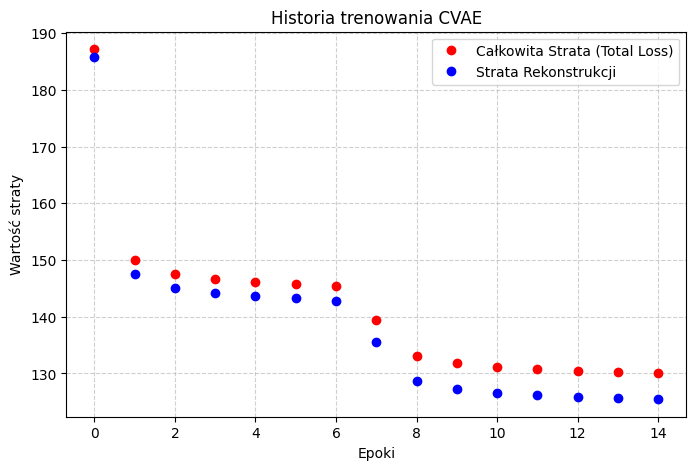

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], 'ro', label='Całkowita Strata (Total Loss)')
plt.plot(history.history['reconstruction_loss'], 'bo', label='Strata Rekonstrukcji')
plt.title('Historia trenowania CVAE')
plt.xlabel('Epoki')
plt.ylabel('Wartość straty')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Ćwiczenie 2. Wizualizacja latent space

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step


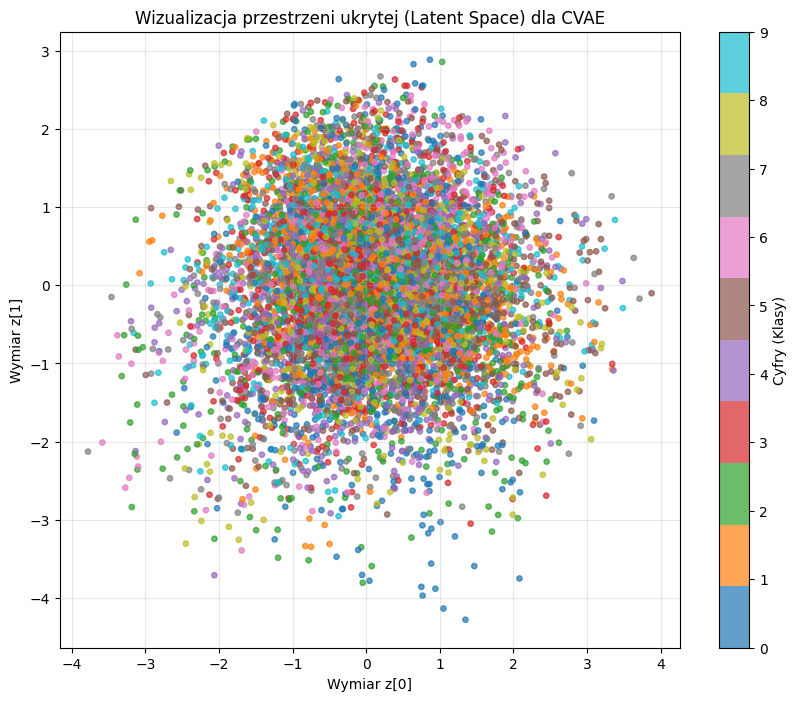

In [51]:
def plot_label_clusters(encoder, data, labels):
    # predykcja przestrzeni ukrytej z enkodera
    z_mean, _, _ = encoder.predict([data, to_categorical(labels, 10)])

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels, cmap="tab10", alpha=0.7, s=15)
    plt.colorbar(scatter, ticks=range(10), label='Cyfry (Klasy)')
    plt.title("Wizualizacja przestrzeni ukrytej (Latent Space) dla CVAE")
    plt.xlabel("Wymiar z[0]")
    plt.ylabel("Wymiar z[1]")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_label_clusters(encoder, x_train[:10000], y_train[:10000])

#### Ćwiczenie 3. Generowanie cyfr na żądanie

In [52]:
def generate_digit(digit_label):
    # losowy punkt w przestrzeni 2D
    random_latent_vector = np.random.normal(size=(1, latent_dim))

    # etykieta żądanej cyfry
    label_condition = np.zeros((1, 10))
    label_condition[0, digit_label] = 1.0

    generated_image = decoder.predict([random_latent_vector, label_condition])

    plt.figure(figsize=(3, 3))
    plt.imshow(generated_image[0].reshape(28, 28), cmap='gray_r')
    plt.title(f"Wygenerowana sztucznie cyfra: {digit_label}", color='blue')
    plt.axis('off')
    plt.show()

Generowanie trzech różnych wariantów cyfry 5:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


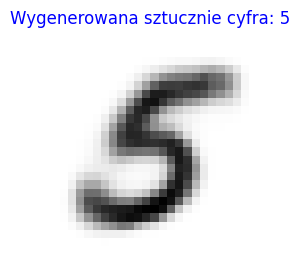

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


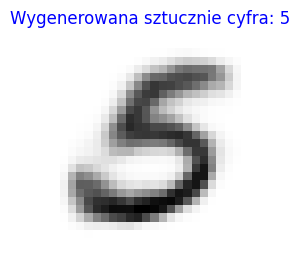

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


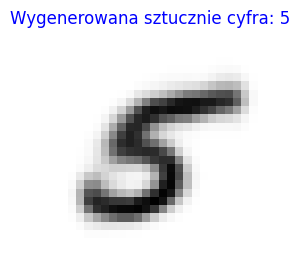

Generowanie cyfry 8:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


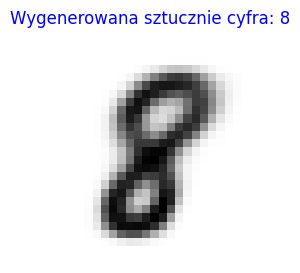

In [53]:
print("Generowanie trzech różnych wariantów cyfry 5:")
for _ in range(3):
    generate_digit(digit_label=5)

print("Generowanie cyfry 8:")
generate_digit(digit_label=8)

#### Ćwiczenie 4 Przeprowadź eksperymenty na CVAE

In [54]:
def run_experiment(latent_dim, beta, epochs=5):
    print(f"\n{'='*50}")
    print(f"Wymiar z = {latent_dim}, Beta KL = {beta}")
    print(f"{'='*50}")

    enc, dec = build_cvae_models(latent_dim)
    cvae = CVAE(enc, dec, beta_kl=beta)
    cvae.compile(optimizer=keras.optimizers.Adam())

    print(f"Trenowanie przez {epochs} epok...")
    cvae.fit([x_train, y_train_cat], epochs=epochs, batch_size=128, verbose=0)

    z_mean, _, _ = enc.predict([x_test[:5000], y_test_cat[:5000]], verbose=0)
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test[:5000], cmap="tab10", alpha=0.7, s=10)
    plt.colorbar(scatter, ticks=range(10))
    plt.title(f"Latent Space (Wymiar={latent_dim}, Beta={beta})")
    plt.grid(True, alpha=0.3)
    plt.show()

#### Eksperyment z różnymi wartościami BETA


Wymiar z = 2, Beta KL = 0.0
Trenowanie przez 5 epok...


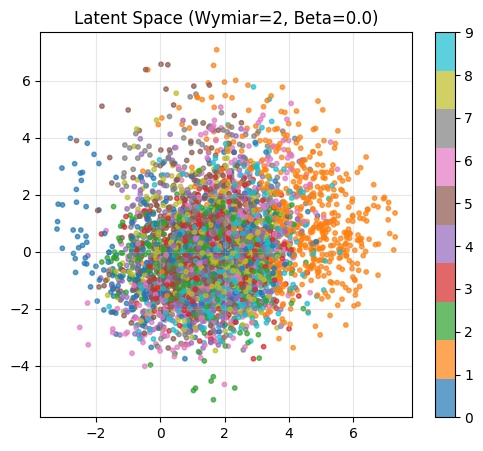


Wymiar z = 2, Beta KL = 0.5
Trenowanie przez 5 epok...


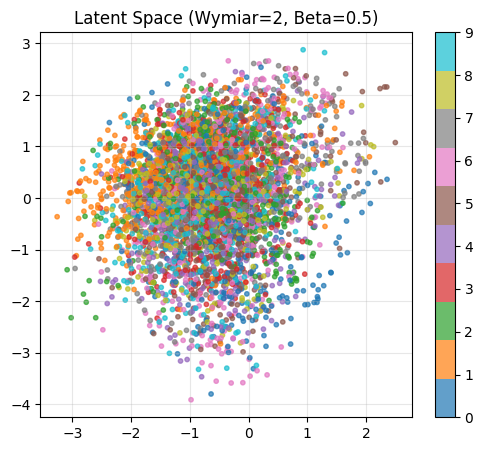


Wymiar z = 2, Beta KL = 1.0
Trenowanie przez 5 epok...


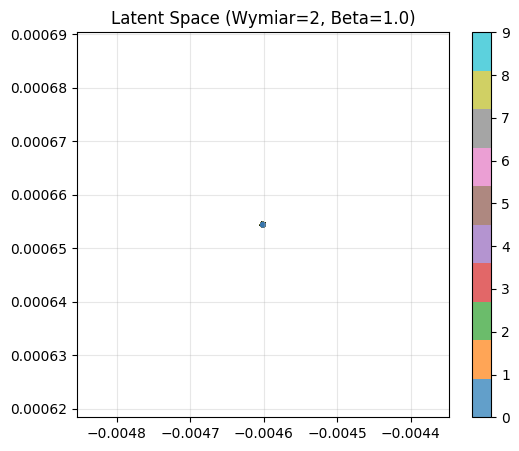


Wymiar z = 2, Beta KL = 1.5
Trenowanie przez 5 epok...


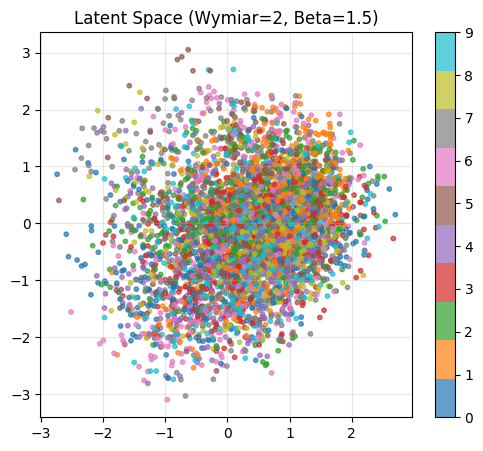


Wymiar z = 2, Beta KL = 2.0
Trenowanie przez 5 epok...


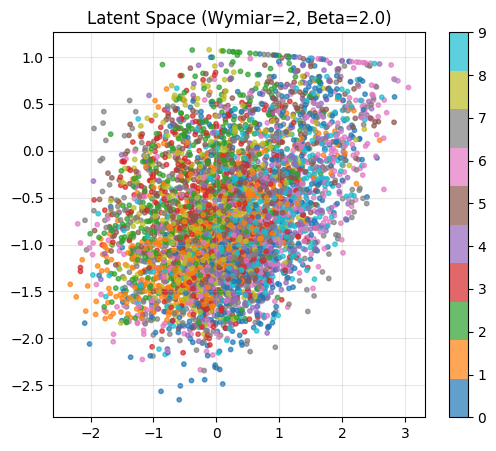

In [55]:
beta_values = [0.0, 0.5, 1.0, 1.5, 2.0]
for b in beta_values:
    run_experiment(latent_dim=2, beta=b, epochs=5)

#### Eksperyment z różnymi wymiarami przestrzeni ukrytej


Wymiar z = 2, Beta KL = 1.0
Trenowanie przez 5 epok...


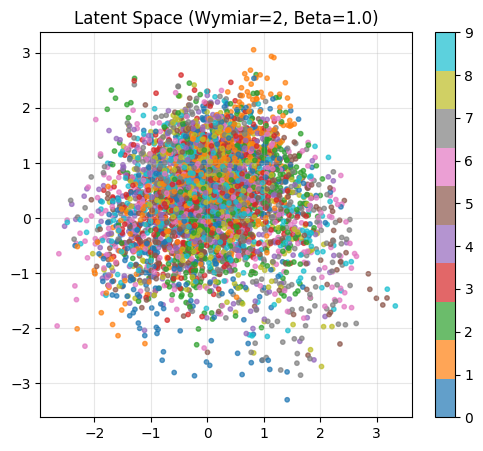


Wymiar z = 5, Beta KL = 1.0
Trenowanie przez 5 epok...


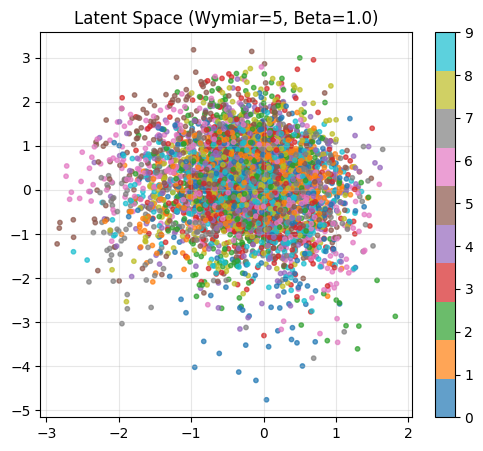


Wymiar z = 10, Beta KL = 1.0
Trenowanie przez 5 epok...


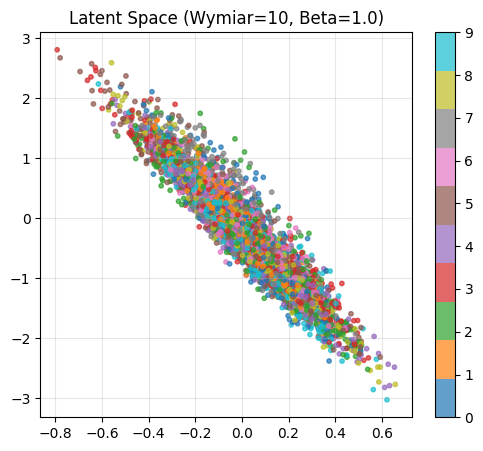

In [56]:
wymiary = [2, 5, 10]
for dim in wymiary:
    run_experiment(latent_dim=dim, beta=1.0, epochs=5)